In [1]:
# %pip install botorch gpytorch  # uncomment if needed

import torch
torch.set_default_dtype(torch.double)
from __future__ import annotations
from typing import Callable
import math
from botorch.optim.optimize import optimize_acqf_mixed
from tests import AugmentedRosenbrock
from botorch.test_functions.multi_fidelity import AugmentedHartmann, AugmentedBranin
from botorch.exceptions.errors import ModelFittingError
#, BoreholeMultiFidelity, WingWeightMultiFidelity
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms import Standardize
from botorch.models.transforms.input import Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
import copy
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.acquisition import PosteriorMean
from botorch.acquisition.multi_step_lookahead import qMultiStepLookahead
from botorch.acquisition.analytic import AnalyticAcquisitionFunction
from botorch.utils.transforms import t_batch_mode_transform
from botorch.optim import optimize_acqf
import matplotlib.pyplot as plt
import torch
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
import warnings
warnings.filterwarnings('ignore')
import time 
import gpytorch
from torch.distributions import Normal


tkwargs = {"dtype": torch.double, "device": "cpu"}
device = torch.device("cpu")
dtype = torch.double



In [2]:

# ---------------------------
# 1) Cost-aware MF stage value
# ---------------------------

class CostAwarePosteriorMeanMF(AnalyticAcquisitionFunction):
    """
    Stage value: mu_hi(x) * rho((x,s),(x,s_hi)) * [ cost(s_hi) / cost(s) ].
    Analytic ⇒ requires q=1 at that stage.
    """

    def __init__(
        self,
        model,
        fid_dim: int,
        target_fidelity: float,
        cost_fn: Callable[[torch.Tensor], torch.Tensor],
        eps: float = 1e-9,
        posterior_transform=None,   # accept & forward this
        debug: bool = False,         # NEW: debug flag
        max_debug_calls: int = 6,   # limit how much we print
        **kwargs,
    ):
        super().__init__(model=model, posterior_transform=posterior_transform)
        self.fid_dim = int(fid_dim)
        self.s_hi = float(target_fidelity)
        self.cost_fn = cost_fn
        self.eps = eps
        self._dbg = debug
        self._dbg_count = 0
        self._dbg_limit = int(max_debug_calls)

    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # X_in has shape (..., 1, d); keep q=1 for model.posterior
        X_in = X                                # (..., 1, d)

        # We'll still peel out a view without q to manipulate the fidelity,
        # but we will add q back before calling posterior.
        X0 = X_in[..., 0, :]                    # (..., d)

        d   = X0.size(-1)
        fid = self.fid_dim if self.fid_dim >= 0 else d + self.fid_dim

        xd = torch.cat([X0[..., :fid], X0[..., fid+1:]], dim=-1)   # (..., d-1)
        s  = X0[..., fid]                                          # (...)

        s_hi = torch.full_like(s, self.s_hi)

        # build points WITH an explicit q-dimension
        X_hi  = torch.cat([xd, s_hi.unsqueeze(-1)], dim=-1).unsqueeze(-2)  # (..., 1, d)
        X_s   = torch.cat([xd,  s .unsqueeze(-1)], dim=-1).unsqueeze(-2)   # (..., 1, d)
        X_pair= torch.cat([X_s, X_hi], dim=-2)                              # (..., 2, d)

        # ---------- DEBUG PRINTS (first few calls only) ----------
        if self._dbg and self._dbg_count < self._dbg_limit:
            try:
                trX = self.model.train_inputs[0]
                tr_bs = tuple(trX.shape[:-2])
            except Exception:
                tr_bs = ("<unknown>",)
            print(
                "[CostAwarePMMF] call", self._dbg_count,
                "| model_batch:", tr_bs,
                "| Xin:", tuple(X_in.shape),
                "| X:", tuple(X.shape),
                "| X_s:", tuple(X_s.shape),
                "| X_hi:", tuple(X_hi.shape),
                "| X_pair:", tuple(X_pair.shape),
            )
            self._dbg_count += 1
        # ---------------------------------------------------------

        # posterior at high fidelity
        post_hi = self.model.posterior(X_hi, posterior_transform=self.posterior_transform)
        # shapes: mean (..., 1, 1) for single-output → squeeze both last dims
        mu_hi = post_hi.mean.squeeze(-1).squeeze(-1)                         # (...)

        # correlation between (x,s) and (x,s_hi)
        post_pair = self.model.posterior(X_pair, posterior_transform=self.posterior_transform)
        cov = post_pair.mvn.covariance_matrix                                # (..., 2, 2)
        var_s  = cov[..., 0, 0].clamp_min(self.eps)
        var_hi = cov[..., 1, 1].clamp_min(self.eps)
        rho = (cov[..., 0, 1] / (var_s.clamp_min(1e-12).sqrt() * var_hi.clamp_min(1e-12).sqrt()))

        # cost ratio
        cost_hi = self.cost_fn(s_hi)
        cost_s  = self.cost_fn(s)
        cost_ratio = (cost_hi / cost_s)
        val = (mu_hi * rho  * (cost_ratio)).nan_to_num(neginf=0.0, posinf=0.0)
        return val


In [3]:

# def make_cost_fn_from_dict(cost_dict: dict[float, float]):
#     keys = torch.tensor(sorted(float(k) for k in cost_dict.keys()))
#     vals = torch.tensor([cost_dict[float(k)] for k in keys.tolist()])

#     def cost_fn(s: torch.Tensor) -> torch.Tensor:
#         k = keys.to(device=s.device, dtype=s.dtype)  # (K,)
#         v = vals.to(device=s.device, dtype=s.dtype)  # (K,)
#         idx = torch.argmin((s.unsqueeze(-1) - k).abs(), dim=-1)  # same shape as s
#         return v[idx]  # advanced indexing works for any shape
#     return cost_fn

import torch

def make_cost_fn_from_dict(cost_dict: dict[float, float],
                           *,
                           dtype: torch.dtype = torch.double,
                           device: torch.device | None = None):
    """
    Build a nearest-neighbour cost function from a {fidelity: cost} table.
    Robust to float precision; no dict lookups from tensor floats.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1) Create a stable, Python-float list once
    klist = sorted(float(k) for k in cost_dict.keys())
    vlist = [float(cost_dict[k]) for k in klist]

    # 2) Turn them into tensors
    keys = torch.tensor(klist, dtype=dtype, device=device)   # (K,)
    vals = torch.tensor(vlist, dtype=dtype, device=device)   # (K,)

    # 3) Nearest-neighbour lookup (handles batched s)
    def cost_fn(s: torch.Tensor) -> torch.Tensor:
        k = keys.to(device=s.device, dtype=s.dtype)
        v = vals.to(device=s.device, dtype=s.dtype)
        idx = (s.unsqueeze(-1) - k).abs().argmin(dim=-1)     # same shape as s
        return v[idx]                                        # (...,)

    return cost_fn


def _normalize_vf_and_args(valfunc_cls, argfac, k: int = 2):
    """
    k = number of lookahead steps. For k=2 we need 3 entries (stage1, stage2, terminal).

    valfunc_cls: None | class | list/tuple of classes (len=k+1)
    argfac:      None | callable | list/tuple of callables/None (len=k+1)

    Returns: (vf_list, arg_list), both lists of length k+1.
    """
    # ---- value function classes ----
    if valfunc_cls is None:
        # default to your cost-aware PM at all stages
        vf_list = [CostAwarePosteriorMeanMF] * (k + 1)
    elif isinstance(valfunc_cls, (list, tuple)):
        if len(valfunc_cls) != (k + 1):
            raise ValueError(f"valfunc_cls must have length {k+1}, got {len(valfunc_cls)}")
        vf_list = list(valfunc_cls)
    else:
        vf_list = [valfunc_cls] * (k + 1)

    # ---- argument factories ----
    if argfac is None:
        arg_list = [None] * (k + 1)
    elif isinstance(argfac, (list, tuple)):
        if len(argfac) != (k + 1):
            raise ValueError(f"argfac must have length {k+1}, got {len(argfac)}")
        arg_list = list(argfac)
    elif callable(argfac):
        arg_list = [argfac] * (k + 1)
    else:
        raise TypeError("argfac must be None, a callable, or a list/tuple of callables/None")

    return vf_list, arg_list





In [4]:
class MFEI(AnalyticAcquisitionFunction):
    """
    Cost-aware multi-fidelity EI for q=1 and continuous fidelities.

    For a candidate X (shape: batch x 1 x d) with x in first dim_x dims
    and fidelity dims in the last one or two dims, the stage value is:

        EI_hi(x) * ρ((x,s), (x,s_hi)) * sqrt( cost(s_hi) / cost(s) )

    where:
      - EI_hi(x) is analytic EI at the *high* fidelity s_hi
      - ρ is the posterior correlation between (x,s) and (x,s_hi)
      - cost(·) is given by an AffineFidelityCostModel
    """

    def __init__(
        self,
        model,
        dim_x: int,
        s_hi: float,
        cost_model: AffineFidelityCostModel,
        best_f: float,
        eps: float = 1e-9,
        posterior_transform=None,
        debug: bool = False,
        max_debug_calls: int = 6,
        **kwargs,
    ):
        super().__init__(model=model, posterior_transform=posterior_transform)
        self.dim_x        = int(dim_x)
        self.s_hi         = float(s_hi)
        self.cost_model   = cost_model
        # self.best_f       = float(best_f)
        best_f_t = torch.as_tensor(
            best_f,
            dtype=model.train_targets.dtype,
            device=model.train_targets.device,
        )
        self.register_buffer("best_f", best_f_t)
        self.eps          = eps
        self._dbg         = debug
        self._dbg_count   = 0
        self._dbg_limit   = int(max_debug_calls)

        # standard normal for EI formula
        self._std_normal = Normal(
            torch.zeros(
                1,
                dtype=model.train_targets.dtype,
                device=model.train_targets.device,
            ),
            torch.ones(
                1,
                dtype=model.train_targets.dtype,
                device=model.train_targets.device,
            ),
        )

    def _stats(self, name: str, t: torch.Tensor):
        """Print shape + basic stats – robust to empty tensors."""
        if not self._dbg:
            return
        s = f"{name:10}  shape={tuple(t.shape)}"
        if t.numel() == 0:
            print(s + "  EMPTY")
            return
        with torch.no_grad():
            s += (
                f"  min={float(t.min()):.3e}  max={float(t.max()):.3e}  "
                f"nan={(~torch.isfinite(t)).sum().item()}  "
                f"inf={(torch.isinf(t)).sum().item()})"
            )
        print(s)

    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        X: batch_shape x 1 x d
        """
        if self._dbg:
            print(f"\n==== forward call {self._dbg_count} ====")
            self._dbg_count += 1
            self._stats("X in", X)

        # Extract single point per batch: (..., d)
        X0 = X[..., 0, :]
        d_total = X0.shape[-1]
        dim_x = self.dim_x

        # Split into design and fidelity parts
        xd = X0[..., :dim_x]                # (..., dim_x)
        s  = X0[..., dim_x:]                # (..., n_fid)  with n_fid = d_total - dim_x

        # Build high-fidelity point (same x, all fidelities = s_hi)
        s_hi = torch.full_like(s, self.s_hi)
        X_hi0 = torch.cat([xd, s_hi], dim=-1)   # (..., d_total)
        X_s0  = X0                              # (..., d_total)

        # Stack (x, s) and (x, s_hi) for joint posterior
        X_pair = torch.stack([X_s0, X_hi0], dim=-2)   # (..., 2, d_total)
        self._stats("X_pair", X_pair)

        # Posterior for both fidelities at once
        with gpytorch.settings.fast_pred_var(True):
            post_pair = self.model.posterior(
                X_pair,
                posterior_transform=self.posterior_transform,
                observation_noise=False,
            )

        # Means / variances
        mean2 = post_pair.mean.squeeze(-1)                     # (..., 2)
        mu_hi = mean2[..., 1]

        var2  = post_pair.variance.squeeze(-1).clamp_min(self.eps)  # (..., 2)
        var_ss, var_hh = var2[..., 0], var2[..., 1]

        # Off-diagonal covariance Cov[(x,s), (x,s_hi)]
        mvn = post_pair.mvn
        cov_sh = mvn.covariance_matrix[..., 0, 1]              # (...,)

        # Correlation ρ
        rho = (cov_sh / (var_ss.sqrt() * var_hh.sqrt())).clamp(-1.0, 1.0)
        self._stats("rho", rho)

        # Analytic EI at high fidelity using mu_hi, var_hh
        sigma = var_hh.sqrt()
        z     = (mu_hi - self.best_f) / sigma
        cdf_z = self._std_normal.cdf(z)
        log_pdf_z = self._std_normal.log_prob(z)
        ei    = (mu_hi - self.best_f) * cdf_z + sigma * torch.exp(log_pdf_z)
        self._stats("EI", ei)

        # Cost ratio: cost(x, s_hi) / cost(x, s)
        # cost_model expects shape (..., q, d), so give q=1
        cost_hi = self.cost_model(X_hi0.unsqueeze(-2)).squeeze(-1).squeeze(-1)
        cost_s  = self.cost_model(X).squeeze(-1).squeeze(-1)
        cost_ratio = cost_hi / cost_s
        self._stats("cost ratio", cost_ratio)

        # Final value
        val = ei * (torch.sign(rho) * (rho.abs())) * (cost_ratio)
        self._stats("val", val)

        return val


In [5]:
def draw_initial(
    f,
    n: int = 20,
    flag_two_fid: bool = False,
):
    """
    Generate an initial design with *continuous* fidelities.

    flag_two_fid = False  -> layout [x_part , s]
    flag_two_fid = True   -> layout [x_part , s1 , s2]

    Assumes:
      - f.dim is the total input dimension
      - The last 1 (or 2) dimensions of f.bounds are fidelity dims.
    """

    # number of pure design dimensions
    dim_x = f.dim - (2 if flag_two_fid else 1)
    bounds = f.bounds.clone().to(dtype=dtype, device=device)

    # ------------------------------------------------------------------#
    # 1) sample design variables x in their physical bounds
    # ------------------------------------------------------------------#
    low_x  = bounds[0, :dim_x]        # (dim_x,)
    high_x = bounds[1, :dim_x]        # (dim_x,)

    u_x    = torch.rand(n, dim_x, dtype=torch.double, device=device)
    x_part = low_x + (high_x - low_x) * u_x      # (n , dim_x)

    # ------------------------------------------------------------------#
    # 2) sample continuous fidelity variable(s) from their bounds
    # ------------------------------------------------------------------#
    n_fid   = 2 if flag_two_fid else 1
    low_s   = bounds[0, dim_x: dim_x + n_fid]    # (n_fid,)
    high_s  = bounds[1, dim_x: dim_x + n_fid]    # (n_fid,)

    u_s     = torch.rand(n, n_fid, dtype=torch.double, device=device)
    s_part  = low_s + (high_s - low_s) * u_s     # (n, n_fid)

    # ------------------------------------------------------------------#
    # 2b) Force a proportion of initial points to be at highest fidelity
    # ------------------------------------------------------------------#
    # Choose how many high-fidelity points you want in the initial design.
    # Here: 20% of n (at least 1), change 0.20 to whatever proportion you want.
    hf_prop = 0.20
    n_hf = max(1, int(round(hf_prop * n)))

    # Randomly pick which rows become high-fidelity
    idx = torch.randperm(n, device=device)[:n_hf]

    # Set all fidelity dims to 1.0 for those rows
    s_part[idx, :] = 1.0

    # ------------------------------------------------------------------#
    # 3) build the full X matrix
    # ------------------------------------------------------------------#
    X0 = torch.cat([x_part, s_part], dim=-1)      # (n , dim_x + n_fid)

    Y0 = f(X0).unsqueeze(-1)
    return X0, Y0

def best_f_from_model_high_fidelity_raw(model, fid_dims, s_hi=1.0, tol=1e-2):
    train_X = model.train_inputs[0]      # (..., n, d)
    train_y_t = model.train_targets      # (..., n)  (transformed if Standardize)

    # untransform targets back to raw objective scale (because you use model.posterior -> raw scale)
    ot = getattr(model, "outcome_transform", None)
    if ot is not None:
        out = ot.untransform(train_y_t.unsqueeze(-1), None)
        train_y = (out[0] if isinstance(out, tuple) else out).squeeze(-1)  # (..., n)
    else:
        train_y = train_y_t
    # mask high-fidelity rows
    mask = torch.ones(train_X.shape[:-1], dtype=torch.bool, device=train_X.device)  # (..., n)
    for d in fid_dims:
        mask &= torch.isclose(
            train_X[..., d],
            torch.as_tensor(s_hi, dtype=train_X.dtype, device=train_X.device),
            atol=tol, rtol=0.0,
        )

    neg_inf = torch.tensor(-float("inf"), dtype=train_y.dtype, device=train_y.device)
    y_masked = torch.where(mask, train_y, neg_inf)
    best_hf = y_masked.max(dim=-1).values  # (...)  (fantasy-batched if fantasy model)


    # fallback if no HF exists in some batch
    has_hf = mask.any(dim=-1)
    best_any = train_y.max(dim=-1).values
    best = torch.where(has_hf, best_hf, best_any)
    return best

def fit_mf_gp(X: torch.Tensor, Y: torch.Tensor, fid_dims) -> SingleTaskMultiFidelityGP:
    # Allow passing a single int or a list of ints
    if isinstance(fid_dims, int):
        fid_dims = [fid_dims]

    model = SingleTaskMultiFidelityGP(
        train_X=X,
        train_Y=Y,
        data_fidelities=fid_dims,
        linear_truncated=True,
        outcome_transform=Standardize(m=1),
    ).to(dtype=torch.double, device=device)

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model


In [6]:
import torch

@torch.no_grad()
def best_f_from_model_high_fidelity_raw_max_then_untransform(
    model, fid_dims, s_hi=1.0, tol=1e-2
):
    train_X = model.train_inputs[0]      # (..., n, d)
    train_y_t = model.train_targets      # (..., n)  (transformed if Standardize)

    # mask high-fidelity rows
    mask = torch.ones(train_X.shape[:-1], dtype=torch.bool, device=train_X.device)  # (..., n)
    s_hi_t = torch.as_tensor(s_hi, dtype=train_X.dtype, device=train_X.device)
    for d in fid_dims:
        mask &= torch.isclose(
            train_X[..., d],
            s_hi_t,
            atol=tol, rtol=0.0,
        )

    # maxima in transformed space
    neg_inf_t = torch.tensor(-float("inf"), dtype=train_y_t.dtype, device=train_y_t.device)
    y_t_masked = torch.where(mask, train_y_t, neg_inf_t)
    best_hf_t = y_t_masked.max(dim=-1).values   # (...) transformed-space HF max

    has_hf = mask.any(dim=-1)
    best_any_t = train_y_t.max(dim=-1).values   # (...) transformed-space overall max
    best_t = torch.where(has_hf, best_hf_t, best_any_t)

    # untransform only the final max values (back to raw objective scale)
    ot = getattr(model, "outcome_transform", None)
    if ot is None:
        return best_t

    # IMPORTANT: untransform expects (..., n, m); here n=1, m=1
    out = ot.untransform(best_t[..., None, None], None)
    y = out[0] if isinstance(out, tuple) else out
    return y[..., 0, 0]

In [7]:
import torch

@torch.no_grad()
def best_f_from_model_high_fidelity_raw_vec(
    model, fid_dims, s_hi=1.0, tol=1e-2, const_cache=None
):
    X = model.train_inputs[0]   # (..., n, d)
    y_t = model.train_targets   # (..., n), transformed if Standardize
    if const_cache is None:
        const_cache = {}

    # Cache tiny constants only (safe across refits/fantasies)
    k_idx = ("fid_idx", X.device, tuple(fid_dims))
    fid_idx = const_cache.get(k_idx)
    if fid_idx is None:
        fid_idx = torch.as_tensor(fid_dims, device=X.device, dtype=torch.long)
        const_cache[k_idx] = fid_idx

    k_hi = ("s_hi", X.device, X.dtype, float(s_hi))
    s_hi_t = const_cache.get(k_hi)
    if s_hi_t is None:
        s_hi_t = torch.as_tensor(s_hi, device=X.device, dtype=X.dtype)
        const_cache[k_hi] = s_hi_t

    # Vectorized HF mask (no Python loop over fid_dims)
    X_fid = X.index_select(-1, fid_idx)  # (..., n, k)
    if tol == 0:
        mask = X_fid.eq(s_hi_t).all(dim=-1)
    else:
        mask = (X_fid - s_hi_t).abs().le(tol).all(dim=-1)

    has_hf = mask.any(dim=-1)
    best_hf_t = y_t.masked_fill(~mask, -torch.inf).amax(dim=-1)
    best_any_t = y_t.amax(dim=-1)
    best_t = torch.where(has_hf, best_hf_t, best_any_t)

    # Untransform only the final max, not all train_targets
    ot = getattr(model, "outcome_transform", None)
    if ot is None:
        return best_t
    # IMPORTANT: untransform expects (..., n, m); here n=1, m=1
    out = ot.untransform(best_t[..., None, None], None)
    y = out[0] if isinstance(out, tuple) else out
    return y[..., 0, 0]


In [25]:
from botorch.acquisition import PosteriorMean
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.models.cost import AffineFidelityCostModel
import time
import numpy as np
argfac_inner_calls = 0
argfac_inner_time = 0.0
bestf_time = 0.0
# ---------------------------
# 4) BO loop (2-step, cost-aware)
# ---------------------------

def run_cost_aware_mf_bo_once(
    f: Callable,
    T: int = 30,
    init_n: int = 16,
    s_hi: float = 1.0, 
    cost_dict: dict | None = None,
    seed: int | None = None,
    per_run_plots: bool = True,
    flag_two_fid: bool = False,
    valfunc_cls=None,   
    argfac=None,
    batch_sizes=None,
    num_fantasies=None,
):
    """
    Returns dict with:
      - cum_cost: [T] cumulative cost
      - best_hi:  [T] best observed at s=1.0 (forward-filled)
    """
    import torch  
    if seed is not None:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))


    # ---------------------------------------------------------------
    # Dimensions & fidelity indices
    # ---------------------------------------------------------------
    if flag_two_fid:
        dim_x   = f.dim - 2
        d_total = f.dim
        fid_dims = [f.dim - 2, f.dim - 1]   # last two dims are fidelities
    else:
        dim_x   = f.dim - 1
        d_total = f.dim
        fid_dims = [f.dim - 1]              # last dim is fidelity

    bounds = f.bounds.clone().detach().to(**tkwargs)

    # ---------------------------------------------------------------
    # Affine cost model: cost = fixed_cost + Σ w_j * s_j
    # (s_j are the fidelity coordinates)
    # ---------------------------------------------------------------
    if cost_dict is None:
        # reasonable default
        cost_dict = {"fixed_cost": 1.0, "w": 1.0}

    fixed_cost = float(cost_dict.get("fixed_cost", 1.0))
    if len(fid_dims) == 1:
        w = float(cost_dict.get("w", 1.0))
        fidelity_weights = {fid_dims[0]: w}
    else:
        w1 = float(cost_dict.get("w1", 1.0))
        w2 = float(cost_dict.get("w2", 1.0))
        fidelity_weights = {
            fid_dims[0]: w1,
            fid_dims[1]: w2,
        }

    cost_model = AffineFidelityCostModel(
        fidelity_weights=fidelity_weights,
        fixed_cost=fixed_cost,
    )   

    # --- initial design
    X, Y = draw_initial(f, init_n, flag_two_fid=flag_two_fid)
    print(f"X values are : {X.tolist()}")
    print(f"Y values are : {Y.squeeze(-1).tolist()}")    
    
    # --- trackers
    iter_idx, y_at_iter, s_at_iter = [], [], []
    best_hi_hist, cost_at_iter, cum_cost_hist = [], [], []
    total_cost = 0.0
    prev_best = float('-inf')
    hf_interval = 5
    iters_since_hf = 0


    # ---- BO loop ---- 
    for t in range(T):

        model = fit_mf_gp(X, Y, fid_dims)  

        # Current best at high fidelity s_hi in *all* fidelity dims
        tol = 1.1e-2
        hf_mask = torch.ones(X.shape[0], dtype=torch.bool, device=X.device)
        for d in fid_dims:
            hf_mask &= torch.isclose(
                X[:, d],
                torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                atol=tol, rtol=0.0,
            )



        y_max = Y[hf_mask].max()


        best_f_value = float(y_max.item())

        # Strict trigger: if we have gone `hf_interval` BO iterations
        # without evaluating HF, force the next iteration to HF.
        hf_exploit = iters_since_hf >= (hf_interval - 1)
        

        # outer: use incumbent from real dataset (constant)
        def argfac_outer(model, X):
            return {
                "dim_x": dim_x,
                "s_hi": s_hi,
                "cost_model": cost_model,
                "best_f": best_f_value,   # scalar is fine
            }

        # inner: recompute from the (fantasy) model -> best_f varies across fantasies
        def argfac_inner(model, X):
            best_f_inner = best_f_from_model_high_fidelity_raw_max_then_untransform(model, fid_dims=fid_dims, s_hi=s_hi, tol=tol)
            return {
                "dim_x": dim_x,
                "s_hi": s_hi,
                "cost_model": cost_model,
                "best_f": best_f_inner,   # tensor, fantasy-batched
            }
        

        if valfunc_cls is not None and argfac is None:
            argfac_cls = [argfac_outer] + [(argfac_inner if cls is not None else None) for cls in valfunc_cls[1:]]
            # print("Using value function class:",
            #       [cls.__name__ if cls is not None else None for cls in valfunc_cls])
            # print("argfac_cls is:",
            #       [fn.__name__ if fn is not None else None for fn in argfac_cls])

        batch_sizes1 = [1] * ((len(valfunc_cls)-1) if valfunc_cls else batch_sizes)  # default to q=1 at all stages

        
        if hf_exploit:
            print(f"Iter {t+1:02d} | forcing HF qMultiStepLookahead step")

            acq_hf = qMultiStepLookahead(
                model=model,
                batch_sizes=batch_sizes1,
                num_fantasies=num_fantasies,
                valfunc_cls=valfunc_cls,
                valfunc_argfacs=argfac_cls,
            )
            qprime = int(acq_hf.get_augmented_q_batch_size(q=1))
            fixed_features = {d: float(s_hi) for d in fid_dims}

            new_x, acq_val_s = optimize_acqf(
                acq_function=acq_hf,
                bounds=bounds,
                q=qprime,
                num_restarts=12,
                raw_samples=256,
                fixed_features=fixed_features,
                options={"maxiter": 200, "batch_limit": 8, "init_batch_limit": 64},
            )

            new_x = new_x.clone()
            for d in fid_dims:
                new_x[0, d] = torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device)
        else:
            acq = qMultiStepLookahead(
                model=model,
                batch_sizes=batch_sizes1,          # analytic ⇒ q1=q2=1  batch_sizes=[1,1], when f1 and f2 are there 
                num_fantasies= num_fantasies,
                valfunc_cls=valfunc_cls,
                valfunc_argfacs=argfac_cls,
                )
            qprime = int(acq.get_augmented_q_batch_size(q=1))
            print(f"Number of fantasies are {num_fantasies}, so q'={qprime}")
            new_x, acq_val_s = optimize_acqf(
                acq_function=acq,
                bounds=bounds,
                q=qprime,
                num_restarts=12,
                raw_samples=256,
                options={"maxiter": 200, "batch_limit": 8, "init_batch_limit": 64},
            )

        
        with torch.no_grad():
            new_y = f(new_x).view(1, 1)

        tol_hf = 1.1e-2
        is_hf = True
        for d in fid_dims:
            is_hf = is_hf and torch.isclose(
                new_x[0, d],
                torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device),
                atol=tol_hf, rtol=0.0,
            ).item()
        if is_hf:
            iters_since_hf = 0
        else:
            iters_since_hf += 1

        # Cost of this evaluation via affine cost model
        cost_t = cost_model(new_x).squeeze(-1).squeeze(-1).item()
        total_cost += cost_t

        cum_cost_hist.append(total_cost)
        iter_idx.append(t + 1)

        X = torch.cat([X, new_x], dim=0)
        Y = torch.cat([Y, new_y], dim=0)

        # Update best high-fidelity value
        tol = 1.1e-2
        hf_mask = torch.ones(X.shape[0], dtype=torch.bool, device=X.device)
        for d in fid_dims:
            hf_mask &= torch.isclose(
                X[:, d],
                torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                atol=tol, rtol=0.0,
            )

        if hf_mask.any():
            prev_best = Y[hf_mask].max().item()
        current_best = prev_best
        best_hi_hist.append(current_best)

        # Progress print
        if t % 1 == 0 or t == T - 1:
            s_vals = X[-1, fid_dims].tolist()
            s_str = ", ".join(f"{sv:.3f}" for sv in s_vals)
            print(
                f"Iter {t+1:02d} | s=[{s_str}] | y={new_y.item():.6f} "
                f"| cost={cost_t:.6f} | cum_cost={total_cost:.6f} "
                f"| best_hf={current_best:.6f}"
            )



    # ---------------------------------------------------------------
    # Plots
    # ---------------------------------------------------------------
    if per_run_plots:
        plt.figure()
        plt.plot(cum_cost_hist, best_hi_hist, linewidth=1)
        plt.xlabel("Cumulative cost")
        plt.ylabel(f"Best observed @ s≈{s_hi}")
        plt.title("Best high fidelity vs cumulative cost")
        plt.grid(True)
        plt.show()

    # ---------------------------------------------------------------
    # Return results
    # ---------------------------------------------------------------
    return {
        "cum_cost": cum_cost_hist,
        "best_hi":  best_hi_hist,
    }

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tests_pc import SuzukiMFEmulator
from tests import AugmentedBukin, AugmentedRastrigin, AugmentedAckley



def run_single(f, seed, total_iters = 35, valfunc_cls=None, argfac=None, batch_sizes=None, num_fantasies=None):
    """Run a single BO experiment and return a DataFrame of its trajectory.

    Assumes continuous fidelity variable(s) and that run_cost_aware_mfei_bo_once
    interprets cost_dict as:
      - one fidelity dim:  {"fixed_cost": c0, "w": w}
            cost(s) = c0 + w * s
      - two fidelity dims: {"fixed_cost": c0, "w1": w1, "w2": w2}
            cost(s1, s2) = c0 + w1 * s1 + w2 * s2
    """

    # -------------------------------------------------------
    # pick defaults based on the *type* of f
    # -------------------------------------------------------
    if isinstance(f, AugmentedHartmann):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False     # 1 fidelity dim (last column)
        s_hi        = 1.0        # high fidelity at s = 1

    elif isinstance(f, AugmentedBranin):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    elif isinstance(f, AugmentedBukin):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0
        
    elif isinstance(f, AugmentedAckley):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    elif isinstance(f, AugmentedRastrigin):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    elif isinstance(f, SuzukiMFEmulator):
        cost_dict    = {"fixed_cost": 5.0, "w": 1.0}  # cost increases with fidelity
        flag_two_fid = False
        s_hi         = 1.0


    else:
        raise ValueError(
            "Unknown function"
        )



    # Helper passed to the acquisition 
    # def argfac(model, X):
    #     return {
    #         "fid_dim": fid_dim,
    #         "target_fidelity": 1.0,       # high-fidelity index
    #         "cost_fn": cost_fn,
    #     }

    results = run_cost_aware_mf_bo_once(
        f=f,    
        T=total_iters,
        cost_dict=cost_dict,
        init_n=32,
        s_hi=s_hi,
        seed=seed,
        per_run_plots=True,   # turn off individual plots to keep output clean
        flag_two_fid=flag_two_fid,
        valfunc_cls=valfunc_cls,
        argfac=argfac,
        batch_sizes=batch_sizes,
        num_fantasies=num_fantasies,
    )

    df = pd.DataFrame({
        "iteration":       np.arange(1, len(results["cum_cost"]) + 1),
        "cumulative_cost": results["cum_cost"],
        "best_hi":         results["best_hi"],
    })
    #df.to_csv(f"bo_run_seed_{seed}.csv", index=False)
    #print(f"[seed {seed}] Saved → bo_run_seed_{seed}.csv")
    return df

def aggregate_runs(dfs):
    """Stack per-run dataframes and compute mean & std."""
    merged = (
        pd.concat(
            {i: df.set_index("iteration") for i, df in enumerate(dfs)},
            names=["run", "iteration"],
        )
        .reset_index(level="run")
    )
    stats = (
        merged.groupby("iteration")
        .agg(["mean", "std"])  # adds a 2-level column index
    )
    # Flatten multi-index columns: e.g. ('cumulative_cost','mean') → 'cumulative_cost_mean'
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    return stats.reset_index()

def plot_with_band(iterations, mean, std, ylabel, title):
    plt.figure()
    plt.plot(iterations, mean, lw=2, label="mean")
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.25, label="±1 σ")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def plot_best_vs_cost(cost_mean, cost_std, best_mean, best_std,
                      title="Best observed vs. cumulative cost (mean ± 1 σ)",
                      optimum_val=None):
    """
    Scatter-line plot of mean best-observed value vs mean cumulative cost,
    with a shaded ±1 σ region around the best value.
    """
    # sort by cost so the line is monotone
    order = np.argsort(cost_mean)
    cost_mean, best_mean = cost_mean.iloc[order], best_mean.iloc[order]
    best_std            = best_std.iloc[order]

    plt.figure()
    plt.plot(cost_mean, best_mean, lw=2, label="mean trajectory")
    plt.fill_between(cost_mean,
                     best_mean - best_std,
                     best_mean + best_std,
                     alpha=0.25,
                     label="±1 σ (best)")
    if optimum_val is not None:
        plt.axhline(optimum_val, ls="--", label=f"True optimum = {optimum_val}")

    plt.xlabel("Cumulative cost (mean)")
    plt.ylabel("Best observed hi-fidelity value (mean)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



=== Running ackley (iters=60) ===
X values are : [[29.408646552580457, 3.2547709150356354, 6.99659127160308, 1.0], [-26.62221531431235, 4.611210966363991, 30.262612904886815, 0.12653471480029077], [-15.296098423064382, -15.718566255854189, 4.1450320866169434, 1.0], [2.128994293385503, -8.196180578949111, 11.836405092823398, 0.17529624502097463], [28.43670197890571, 11.954503348483541, -24.58878919479817, 0.044979442777552836], [1.6805301297611166, 1.7387530667239943, 22.412599304203113, 0.8029731801645625], [-21.98570738980102, -16.717380286492357, -9.45166331271406, 0.41186848982015034], [-4.62377476398494, -3.0574607614595735, 15.412106929631754, 0.10950294491161194], [-32.176638722917836, -10.884215002436001, 13.845003757096244, 0.49486487986044625], [-22.808596436765598, 22.984801953064846, 13.05157231933552, 0.4148507871994588], [-22.718323909249435, 4.86574900169073, -4.9421038848180245, 0.45293066133258275], [23.877953881923467, 29.85447014527049, 23.203046187098685, 0.73935412

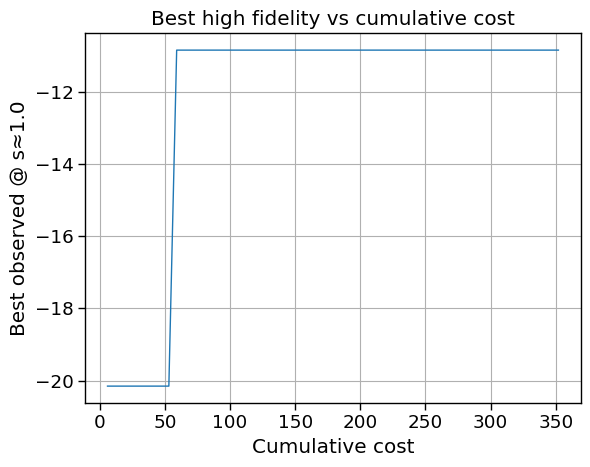

X values are : [[-28.956787608031746, -28.645119267662885, -24.66866313465633, 0.5568278840364884], [-29.322106348432456, 1.7152014322736733, -1.521434375783734, 0.6040106348470814], [29.83432685152775, 28.098729178394102, -27.292901785412056, 0.05836936919045799], [-24.075260909735213, -22.475341987138236, -8.167946187538394, 0.9616452225299865], [22.44737307977232, 24.281156274336396, -8.02600024338862, 0.36697335041217716], [7.368644296297106, -26.993637135838675, 13.18465647082214, 0.3685181023455737], [8.087344470700891, -4.11048360079182, -27.87017500434445, 1.0], [12.021282708302131, -12.305125820139924, -12.513523975895616, 0.5527800061779405], [-30.714090918548894, -30.122543175437045, 28.30557445193719, 0.6961503693253772], [-22.79828177403482, -15.398016663659423, -24.2199106268624, 0.5504868528448952], [-16.262416240389417, -17.47136092189833, -17.97881208547006, 0.46422411911062667], [-11.955876806195185, 7.497861352756715, 6.407543294265814, 0.36873350289403417], [22.8722

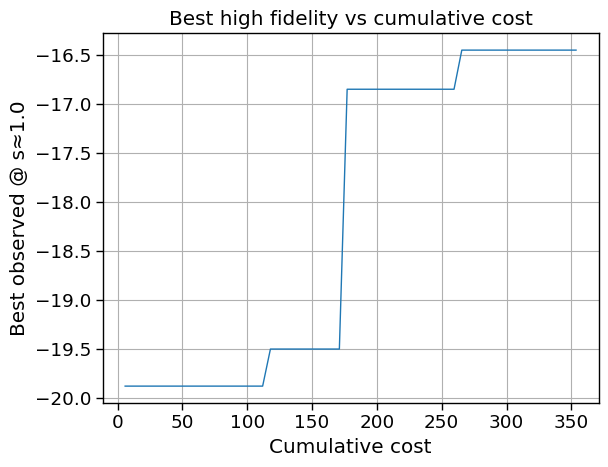

X values are : [[-20.67323099441617, 9.342497120875294, -29.94066711194147, 1.0], [6.0351788194891824, 5.37103848140768, 24.93416031650905, 0.27680219749944457], [-25.624160890509025, -10.862907238576788, 14.186349046043148, 1.0], [7.298238152366785, -29.07721289408202, -16.62677194269882, 0.7909847293189153], [-22.23966664831464, -18.99508448501015, 3.403099807806875, 0.9856853169640366], [16.99206190311618, -5.248062132058376, 3.502442127019954, 1.0], [19.718455400190393, 21.715189736205268, 7.773024373984001, 0.5109384366055939], [-23.904258990089257, -30.8399008691516, 30.63094835216244, 0.8985362271176962], [18.228415156938908, -15.688332554433153, 3.1221196274602434, 0.932986738366961], [32.61673899155352, -12.064143723947556, 24.74929392650371, 1.0], [24.207611763567634, -8.428542244768732, 20.08599947081943, 0.5445649154768258], [10.188666164822152, -3.205478532149179, 7.871135451458393, 0.8884283379909195], [-15.542936096095865, 25.305067756362, 9.40668555373194, 0.08543667773

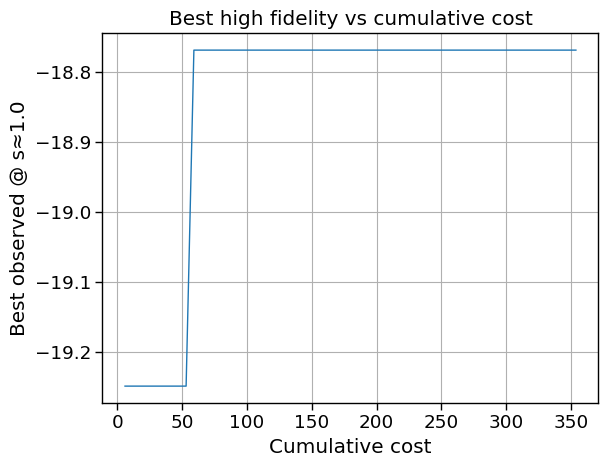

X values are : [[-0.04198974170823533, -31.39928593015618, 30.18314529829309, 0.19750445790101612], [-3.4979713738222777, 32.165522950618794, -4.1785828382223755, 1.0], [27.34221065404487, 6.438299525563814, 25.256482048822782, 0.9541877924517747], [10.023811803141747, 20.576875843290466, 13.20987404332142, 0.45939060548073585], [0.04296626278167537, 17.43892151936071, 19.4849346191142, 1.0], [-20.27130974235181, 25.920634056171473, 6.883080712778948, 0.42843648486553376], [-18.306076292897814, 3.731655071340626, 29.508537739290013, 0.10460563667598599], [8.894736496432841, 22.29227354828761, -16.94216884637988, 0.41116949998238195], [-10.046397961037982, 26.472249366409592, -19.7222890237788, 0.9560688877416299], [-11.37592930008968, 16.474189883286996, -24.551986113018224, 0.028688998843026114], [0.6154661140715874, -3.936065825269587, -30.870117180680406, 0.21104617676571003], [3.5023324327505847, -26.56124546091749, 6.3828042636408, 0.050797977371258685], [-13.504467500606175, 32.0

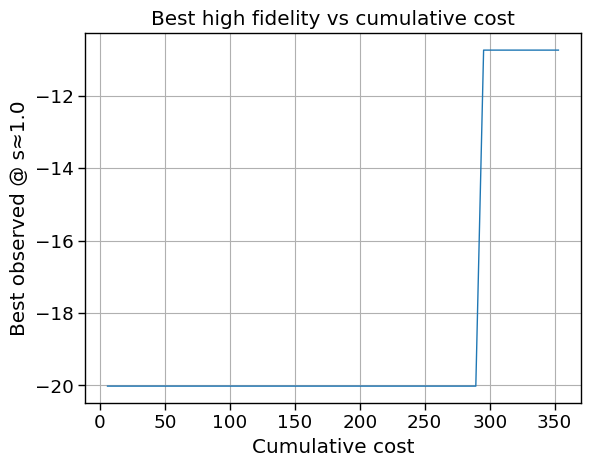

X values are : [[26.458117232000845, 28.726342229779384, 13.632238156549349, 0.21770708827448737], [-26.211692506068655, 24.625118447818025, -26.417214111441417, 0.43889586283615967], [2.0251173792278223, 17.93127871284952, -11.01888033566183, 0.35898630471813486], [-30.042296409588513, -29.843025433202804, -23.020547896341093, 0.6021547793504186], [-16.878964076978782, -14.610170941255799, 12.600611863632153, 0.7684211766252089], [-2.938218842891061, 21.841242399221535, 17.151290856777145, 0.635861767187731], [22.103662795267788, -13.296911196827729, -3.23713422401136, 0.7491828436526841], [23.462827313264235, -3.7306987653885315, 15.753146066408078, 0.3894434640243526], [19.71659957784916, -31.264669508646797, -3.23604726986731, 0.7616666303006222], [30.02194590388946, 7.4377609248088135, 15.860220506042083, 0.7727982999125868], [20.395025082550177, 26.02087439871542, -6.106753456222439, 1.0], [4.622378028509452, -8.510145874756738, -7.0531277207375105, 0.380618994501716], [6.1564075

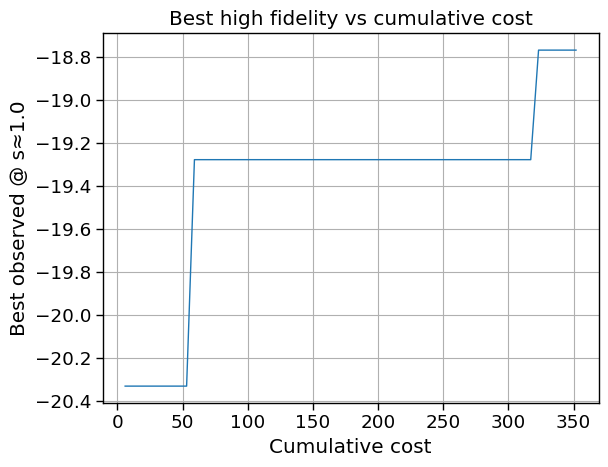

X values are : [[2.5407554430493207, -24.19306304439631, -10.83061881592073, 0.5986909925146792], [-29.96167913141785, 4.243869564111577, 26.223335362734524, 0.3569755546207566], [-22.34962506429349, 13.887219710572353, 27.126223455927835, 0.14063248174553467], [-20.81900930661866, 18.798386716400536, 13.666590851505, 0.3933244956682228], [-5.142212131434164, 19.226338107688278, 20.605222524563274, 1.0], [-28.025553979586075, 26.874775037690107, -10.098404046174167, 0.7531136044360162], [-7.831861153713849, 18.637359945623245, -7.945186385366135, 0.9195950847874662], [-13.159007161131296, -25.06935762525856, 26.79252118348448, 0.3175344734603345], [-15.845358153482945, 27.030649017148143, -27.099865126555795, 0.252511569018957], [17.708997309957965, 11.1940961143126, 23.809845297902662, 0.03722189416018995], [26.614523247789165, -23.76234910242096, 10.401739527701103, 0.10097534823088472], [12.739984748758445, -19.234887721145597, 15.73180455910574, 0.07947364015044933], [-13.901080343

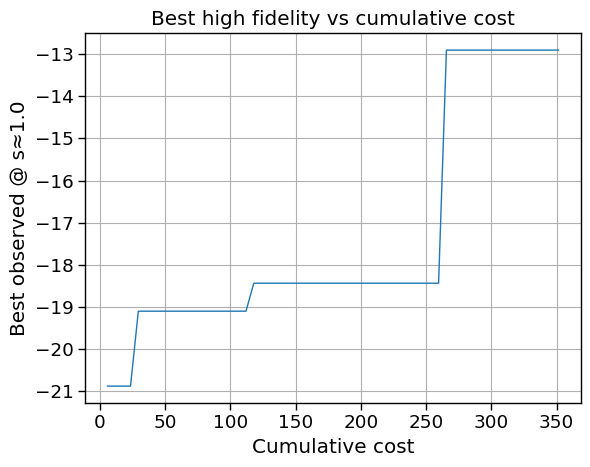

Saved aggregate stats → mf_nonmyo_runs_cont_ackley_30_2_mfei_mfei_mfei.csv


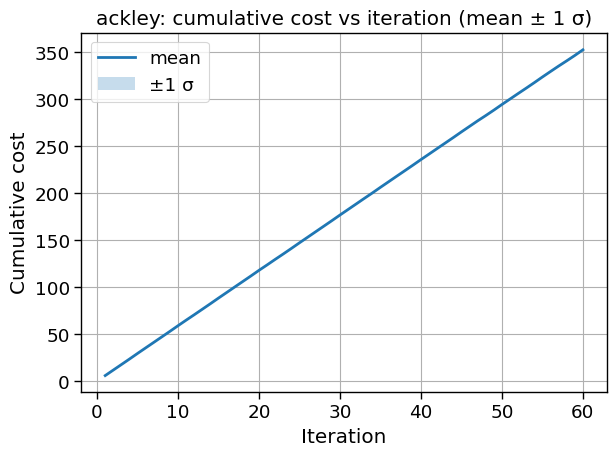

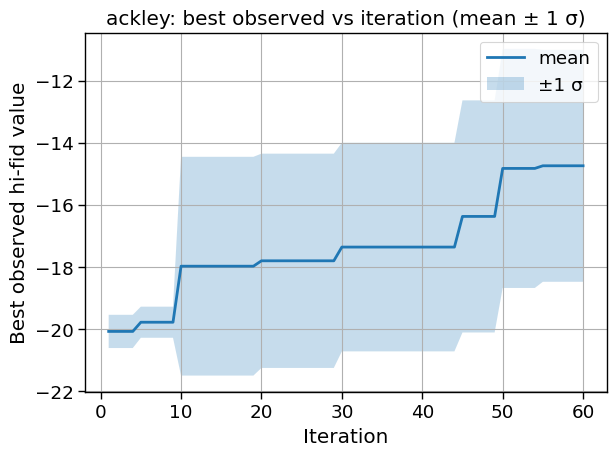

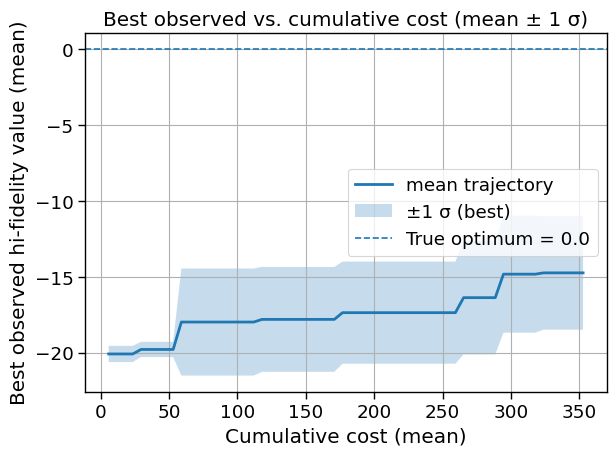

In [37]:
import matplotlib.pyplot as plt
from collections import OrderedDict

# ------------------------------------------------------------------
# 0)  Benchmarks and their custom settings
# ------------------------------------------------------------------
benchmarks = OrderedDict([
    # ("suzuki_mf", (SuzukiMFEmulator(num_samples=32, stochastic=True), 60, None)),
    # ("branin",     (AugmentedBranin(negate=True), 50, -0.3978)),
    # ("hartmann",   (AugmentedHartmann(negate=True), 60,  3.32237)),   
    # ("rastrigin", (AugmentedRastrigin(dim=3, negate=True), 50, -0.0)),
    # ("bukin",     (AugmentedBukin(negate=True), 50, 0.00)),
    ("ackley",  (AugmentedAckley(dim=3, negate=True), 60,  0.0)),
    # ("rosenbrock", (AugmentedRosenbrock(dim=4, negate=True), 50, -0.0)),
    
])

SEEDS = [33,  42, 88, 105, 67, 151]  # 6 runs each 
# ------------------------------------------------------------------
# 1)  Loop over benchmarks
# ------------------------------------------------------------------
for tag, (f, total_iters, opt_val) in benchmarks.items():
    print(f"\n=== Running {tag} (iters={total_iters}) ===")

    # 1a) independent runs
    run_dfs = [run_single(f=f, seed=s, total_iters=total_iters, valfunc_cls=[MFEI, MFEI, MFEI], num_fantasies= [30,2] ) for s in SEEDS]

    # 1b) aggregate & save
    stats_df = aggregate_runs(run_dfs)
    out_csv  = f"mf_nonmyo_runs_cont_{tag}_30_2_mfei_mfei_mfei.csv"
    stats_df.to_csv(out_csv, index=False)
    print(f"Saved aggregate stats → {out_csv}")

    # 1c) plots
    iters = stats_df["iteration"]

    plot_with_band(
        iters,
        stats_df["cumulative_cost_mean"],
        stats_df["cumulative_cost_std"],
        ylabel="Cumulative cost",
        title=f"{tag}: cumulative cost vs iteration (mean ± 1 σ)",
    )

    plot_with_band(
        iters,
        stats_df["best_hi_mean"],
        stats_df["best_hi_std"],
        ylabel="Best observed hi-fid value",
        title=f"{tag}: best observed vs iteration (mean ± 1 σ)",
    )

    plot_best_vs_cost(
        cost_mean=stats_df["cumulative_cost_mean"],
        cost_std=stats_df["cumulative_cost_std"],
        best_mean=stats_df["best_hi_mean"],
        best_std=stats_df["best_hi_std"],
        optimum_val=opt_val,          # show dashed line only if not None
    )
    plt.show()
# ------------------------------------------------------------------

